# (강화된) 미분계산 연습과 나의 감상 나누기 (4기 영상)-09강 4기 23강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x = sp.symbols("x", real=True)
C = sp.symbols("C")


def show_diff(expr):
    d = sp.simplify(sp.diff(expr, x))
    print(f"  d/dx [ {expr} ] = {d}")
    return d


def show_int(expr):
    F = sp.integrate(expr, x)
    print(f"  ∫ {expr} dx = {F}  (+ C)")
    return F

## 0. 곱의 미분 연습
곱의 미분 $(uv)' = u'v + uv'$ 으로 시작하는 첫 세트를 SymPy로 검산합니다.

In [2]:
for e in [(2*x + 1)*sp.exp(x**2), x*sp.cos(x), (x**2 + 1)*sp.sin(x), sp.cos(x)]:
    show_diff(e)

# note가 적은 답과 대조: d/dx[(2x+1)e^{x^2}] = 2 e^{x^2} + (2x+1)·2x·e^{x^2}
lhs = sp.diff((2*x + 1)*sp.exp(x**2), x)
rhs = 2*sp.exp(x**2) + (2*x + 1)*sp.exp(x**2)*2*x
print("note 답과 일치?", sp.simplify(lhs - rhs) == 0)

  d/dx [ (2*x + 1)*exp(x**2) ] = 2*(x*(2*x + 1) + 1)*exp(x**2)
  d/dx [ x*cos(x) ] = -x*sin(x) + cos(x)
  d/dx [ (x**2 + 1)*sin(x) ] = 2*x*sin(x) + (x**2 + 1)*cos(x)
  d/dx [ cos(x) ] = -sin(x)
note 답과 일치? True


## 1. 곱의 미분 — 한 바퀴
$x\ln x$, $x^2\ln x$, $\sqrt{x}\,e^x$, $x^3\sin x$ 등 곱의 미분 모음.
로그가 들어간 항은 **정의역**($x>0$, $x\neq 0$)도 함께 기억합니다.

In [3]:
products = [
    x*sp.ln(x),                    # 1 + ln x   (x>0)
    sp.sin(sp.ln(x)),              # cos(ln x)/x
    x**2*(x**2 + 1),               # expand -> 4x^3 + 2x
    x**2*sp.cos(x),
    sp.ln(sp.Abs(x)),              # 1/x   (x != 0)
    x**3*sp.sin(x),
    (x**2 + 1)*(x**3 - 2),
    x**2*sp.ln(x),                 # 2x ln x + x   (x>0)
    sp.sqrt(x)*sp.exp(x),          # (x>=0)
    x**3*sp.cos(x),
]
for e in products:
    show_diff(e)

  d/dx [ x*log(x) ] = log(x) + 1
  d/dx [ sin(log(x)) ] = cos(log(x))/x
  d/dx [ x**2*(x**2 + 1) ] = 4*x**3 + 2*x
  d/dx [ x**2*cos(x) ] = x*(-x*sin(x) + 2*cos(x))
  d/dx [ log(Abs(x)) ] = Piecewise((0, Eq(x, 0)), (1/x, True))
  d/dx [ x**3*sin(x) ] = x**2*(x*cos(x) + 3*sin(x))
  d/dx [ (x**2 + 1)*(x**3 - 2) ] = x*(5*x**3 + 3*x - 4)
  d/dx [ x**2*log(x) ] = x*(2*log(x) + 1)
  d/dx [ sqrt(x)*exp(x) ] = (x + 1/2)*exp(x)/sqrt(x)
  d/dx [ x**3*cos(x) ] = x**2*(-x*sin(x) + 3*cos(x))


## 2. 합성함수(연쇄법칙)로 들어가기
$(g\circ f)'(x) = g'(f(x))\,f'(x)$. 안쪽 함수를 한 번 더 미분해 곱합니다.
$\ln(\cdot)$ 안은 양수여야 하고, 분모로 가면 0만 아니면 됩니다.

In [4]:
for e in [sp.cos(x)*sp.ln(x + 3), sp.ln(x**2 + 1), sp.exp(x**2), sp.tan(3*x)]:
    show_diff(e)

# d/dx[ln(x^2+1)] = 2x/(x^2+1) 확인
print("ln(x²+1)':", sp.diff(sp.ln(x**2 + 1), x), "==", sp.Rational(0) + 2*x/(x**2 + 1),
      "->", sp.simplify(sp.diff(sp.ln(x**2 + 1), x) - 2*x/(x**2 + 1)) == 0)

  d/dx [ log(x + 3)*cos(x) ] = (-(x + 3)*log(x + 3)*sin(x) + cos(x))/(x + 3)
  d/dx [ log(x**2 + 1) ] = 2*x/(x**2 + 1)
  d/dx [ exp(x**2) ] = 2*x*exp(x**2)
  d/dx [ tan(3*x) ] = 3/cos(3*x)**2
ln(x²+1)': 2*x/(x**2 + 1) == 2*x/(x**2 + 1) -> True


## 3. 지수·로그·합성을 더 섞어서
$e^{3x+2}$, $\ln(\cos x)$, $(1+\sin x)^9$ 처럼 지수·로그·거듭제곱이 합성으로 들어간 것들.
$\ln(\cos x)$ 의 미분 $\dfrac{-\sin x}{\cos x}$ 는 부호가 마이너스, 정의역은 $\cos x>0$.

In [5]:
mixed = [
    sp.exp(3*x + 2),               # 3 e^{3x+2}
    sp.ln(1 - x),                  # -1/(1-x)
    sp.ln(x)*sp.exp(3*x),
    x**2*sp.exp(sp.sin(x)),
    sp.ln(sp.cos(x)),              # -sin x / cos x = -tan x   (cos x > 0)
    sp.sin(4*x + 1),               # 4 cos(4x+1)
    sp.ln(5*x - 7),                # 5/(5x-7)
    sp.sqrt(5*x + 1),              # 5/(2 sqrt(5x+1))
    (1 + sp.sin(x))**9,            # 9(1+sin x)^8 cos x
]
for e in mixed:
    show_diff(e)

  d/dx [ exp(3*x + 2) ] = 3*exp(3*x + 2)
  d/dx [ log(1 - x) ] = 1/(x - 1)
  d/dx [ exp(3*x)*log(x) ] = (3*x*log(x) + 1)*exp(3*x)/x
  d/dx [ x**2*exp(sin(x)) ] = x*(x*cos(x) + 2)*exp(sin(x))
  d/dx [ log(cos(x)) ] = -tan(x)


  d/dx [ sin(4*x + 1) ] = 4*cos(4*x + 1)
  d/dx [ log(5*x - 7) ] = 5/(5*x - 7)
  d/dx [ sqrt(5*x + 1) ] = 5/(2*sqrt(5*x + 1))
  d/dx [ (sin(x) + 1)**9 ] = 9*(sin(x) + 1)**8*cos(x)


## 4. 미분과 적분을 섞기 시작
세 겹 합성 $\dfrac{d}{dx}\sin(\ln(\cos x))$ 와, 거듭제곱·지수·로그 적분(안쪽 미분 보정 + 적분상수 $C$).

In [6]:
print("세 겹 합성:")
show_diff(sp.sin(sp.ln(sp.cos(x))))   # cos(ln(cos x))·(1/cos x)·(-sin x)

print("\n적분 (안쪽 미분 보정에 주의):")
for e in [3/x**2, (x + 1)**2, sp.sin(x), sp.sec(3*x)**2, 1/(5*x - 2)]:
    show_int(e)

# ∫ 1/(5x-2) dx = (1/5) ln|5x-2| : 미분해서 되돌리면 원식이 나오는지 확인
F = sp.Rational(1, 5)*sp.ln(5*x - 2)
print("\n∫1/(5x-2): d/dx[(1/5)ln(5x-2)] =", sp.simplify(sp.diff(F, x)), "(원식 1/(5x-2) 복원)")

세 겹 합성:
  d/dx [ sin(log(cos(x))) ] = -cos(log(cos(x)))*tan(x)

적분 (안쪽 미분 보정에 주의):
  ∫ 3/x**2 dx = -3/x  (+ C)
  ∫ (x + 1)**2 dx = x**3/3 + x**2 + x  (+ C)
  ∫ sin(x) dx = -cos(x)  (+ C)
  ∫ sec(3*x)**2 dx = sin(3*x)/(3*cos(3*x))  (+ C)
  ∫ 1/(5*x - 2) dx = log(5*x - 2)/5  (+ C)

∫1/(5x-2): d/dx[(1/5)ln(5x-2)] = 1/(5*x - 2) (원식 1/(5x-2) 복원)


## 5. 적분을 듬뿍, 함정 문제까지
거듭제곱·지수·로그 적분과 안쪽 미분 보정($\tfrac1{21}$, $\tfrac2{15}$, $\tfrac18$ 등).
함정 문제 $\sqrt{\sin^2 x}+\ln(e^{2x})$ 는 먼저 $\sin x + 2x$ 로 **정리한 뒤** 미분하면 $\cos x + 2$.

In [7]:
print("적분 모음:")
for e in [x**4, x**2, 1/x, (3*x + 1)**6, sp.exp(4*x), sp.sqrt(5*x + 1),
          1/(5*x - 2), 3*x**2 - 4*x + 2, (2*x + 2)**3,
          2*sp.sin(x) - 3*sp.cos(x), 2*x/(x**2 + 10), sp.cos(2*x - 3)]:
    show_int(e)

# 보정 계수 확인: ∫(3x+1)^6 = (1/21)(3x+1)^7,  ∫sqrt(5x+1) = (2/15)(5x+1)^{3/2}
print("\n보정 계수:")
print("  ∫(3x+1)^6 :", sp.integrate((3*x + 1)**6, x), " -> 1/(7·3)=1/21")
print("  ∫(2x+2)^3 :", sp.integrate((2*x + 2)**3, x), " -> 1/(4·2)=1/8")

# 함정 문제: 0<=x<=pi 에서 sqrt(sin^2 x)=sin x, ln(e^{2x})=2x
trap = sp.sqrt(sp.sin(x)**2) + sp.ln(sp.exp(2*x))
simplified = sp.sin(x) + 2*x          # on 0<=x<=pi where sin x >= 0
print("\n함정 문제 정리:  sqrt(sin^2 x)+ln(e^{2x})  ==  sin x + 2x  on [0,pi]")
print("  미분 ->", sp.diff(simplified, x), " (= cos x + 2, 항상 양수)")

적분 모음:
  ∫ x**4 dx = x**5/5  (+ C)
  ∫ x**2 dx = x**3/3  (+ C)
  ∫ 1/x dx = log(x)  (+ C)
  ∫ (3*x + 1)**6 dx = 729*x**7/7 + 243*x**6 + 243*x**5 + 135*x**4 + 45*x**3 + 9*x**2 + x  (+ C)
  ∫ exp(4*x) dx = exp(4*x)/4  (+ C)
  ∫ sqrt(5*x + 1) dx = 2*(5*x + 1)**(3/2)/15  (+ C)
  ∫ 1/(5*x - 2) dx = log(5*x - 2)/5  (+ C)
  ∫ 3*x**2 - 4*x + 2 dx = x**3 - 2*x**2 + 2*x  (+ C)
  ∫ (2*x + 2)**3 dx = 2*x**4 + 8*x**3 + 12*x**2 + 8*x  (+ C)
  ∫ 2*sin(x) - 3*cos(x) dx = -3*sin(x) - 2*cos(x)  (+ C)
  ∫ 2*x/(x**2 + 10) dx = log(x**2 + 10)  (+ C)


  ∫ cos(2*x - 3) dx = sin(2*x - 3)/2  (+ C)

보정 계수:
  ∫(3x+1)^6 : 729*x**7/7 + 243*x**6 + 243*x**5 + 135*x**4 + 45*x**3 + 9*x**2 + x  -> 1/(7·3)=1/21
  ∫(2x+2)^3 : 2*x**4 + 8*x**3 + 12*x**2 + 8*x  -> 1/(4·2)=1/8

함정 문제 정리:  sqrt(sin^2 x)+ln(e^{2x})  ==  sin x + 2x  on [0,pi]
  미분 -> cos(x) + 2  (= cos x + 2, 항상 양수)


### 함정 문제 시각화
겉보기엔 복잡한 $\sqrt{\sin^2 x}+\ln(e^{2x})$ 가 $[0,\pi]$ 에서 $\sin x+2x$ 와 같은 곡선이고,
그 미분 $\cos x+2$ 는 늘 양수($1\le \cos x+2\le 3$)임을 그래프로 확인합니다.

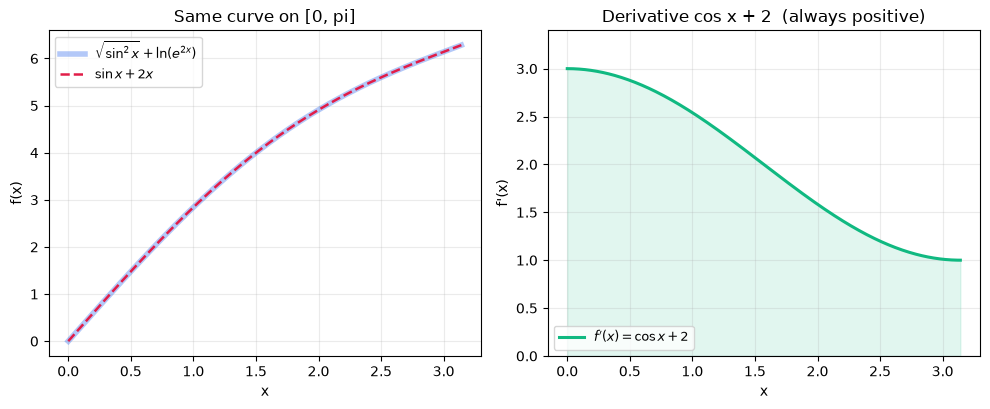

In [8]:
xs = np.linspace(0, np.pi, 400)
f_raw = np.sqrt(np.sin(xs)**2) + np.log(np.exp(2*xs))   # sqrt(sin^2)+ln(e^{2x})
f_simpl = np.sin(xs) + 2*xs                              # sin x + 2x
df = np.cos(xs) + 2                                      # derivative

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2))

ax1.plot(xs, f_raw, color="#2563eb", lw=4, alpha=0.35, label=r"$\sqrt{\sin^2 x}+\ln(e^{2x})$")
ax1.plot(xs, f_simpl, color="#e11d48", lw=1.8, ls="--", label=r"$\sin x + 2x$")
ax1.set_title("Same curve on [0, pi]")
ax1.set_xlabel("x"); ax1.set_ylabel("f(x)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(alpha=0.25)

ax2.plot(xs, df, color="#10b981", lw=2.2, label=r"$f'(x)=\cos x + 2$")
ax2.axhline(0, color="#94a3b8", lw=0.8)
ax2.fill_between(xs, df, 0, color="#10b981", alpha=0.12)
ax2.set_ylim(0, 3.4)
ax2.set_title("Derivative cos x + 2  (always positive)")
ax2.set_xlabel("x"); ax2.set_ylabel("f'(x)")
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(alpha=0.25)

fig.tight_layout()
plt.show()

### 세컨트 → 탄젠트 (미분의 정의)
미분계수는 세컨트 기울기의 극한 $f'(a)=\lim_{h\to0}\dfrac{f(a+h)-f(a)}{h}$.
함정 문제로 정리된 $f(x)=\sin x+2x$ 에서 $a=1$ 일 때 $h\to0$ 으로 세컨트가 탄젠트로 수렴함을 봅니다.

h         secant slope     |secant - f'(a)|
1.0          2.067826       0.472476
0.5          2.312048       0.228254
0.1          2.497364       0.042939
0.01         2.536086       0.004216
0.001        2.539881       0.000421
f'(a) exact = cos(1)+2 = 2.540302


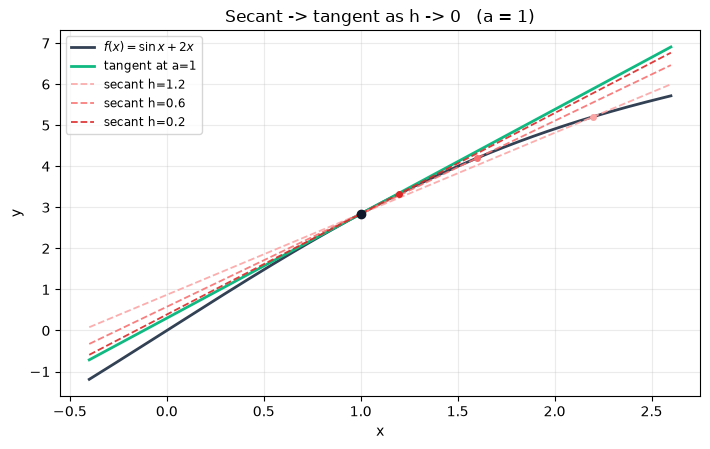

In [9]:
f = lambda t: np.sin(t) + 2*t
a = 1.0
fp_a = np.cos(a) + 2                      # exact derivative at a

print("h         secant slope     |secant - f'(a)|")
for h in [1.0, 0.5, 0.1, 0.01, 0.001]:
    sec = (f(a + h) - f(a)) / h
    print(f"{h:<8} {sec:>12.6f}   {abs(sec - fp_a):>12.6f}")
print(f"f'(a) exact = cos(1)+2 = {fp_a:.6f}")

xs = np.linspace(a - 1.4, a + 1.6, 400)
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(xs, f(xs), color="#334155", lw=2, label=r"$f(x)=\sin x+2x$")
# tangent line at a
ax.plot(xs, f(a) + fp_a*(xs - a), color="#10b981", lw=2, label="tangent at a=1")
# a few secants shrinking toward the tangent
for h, col in zip([1.2, 0.6, 0.2], ["#fca5a5", "#f87171", "#dc2626"]):
    sec = (f(a + h) - f(a)) / h
    ax.plot(xs, f(a) + sec*(xs - a), color=col, lw=1.3, ls="--", alpha=0.9,
            label=f"secant h={h}")
    ax.plot([a, a + h], [f(a), f(a + h)], "o", color=col, ms=4)
ax.plot([a], [f(a)], "o", color="#0f172a", ms=6)
ax.set_title("Secant -> tangent as h -> 0   (a = 1)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(fontsize=8.5, loc="upper left")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()